# Comparison of LLES, APCEMM, and CoCiP data to SUCCESS and CRYSTAL-FACE campaigns

In [1]:
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import re
import glob

# Import functions from the pipeline_fxn_lib.py script
import sys
sys.path.append('/home/chinahg/GCresearch/contrailuncertainty/start_here/')
import pipeline_fxn_lib as lib

plt.rcParams["font.family"] = "FreeSerif"
plt.rcParams["mathtext.fontset"] = "cm"

def removeLow(arr, cutoff = 1e-3):
    func = lambda x: (x > cutoff) * x
    vfunc = np.vectorize(func)
    return vfunc(arr)

# Import CoCiP and APCEMM datasets

In [2]:
cocip_data_130_225 = xr.open_dataset(f'/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/130T225L25/130T225L25-bypass_midnight.nc')
cocip_data_110_205 = xr.open_dataset(f'/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/110T205L25/110T205L25-bypass_midnight.nc')

apcemm_data_130_225 = lib.read_apcemm_data(
    f'/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/1000-bins-optimized/130T225L25/outputs',
)
apcemm_data_110_205 = lib.read_apcemm_data(
    f'/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/1000-bins-optimized/110T205L25/outputs',
)
apcemm_data_110_205 = apcemm_data_110_205.ds_t
apcemm_data_130_225 = apcemm_data_130_225.ds_t

In [ ]:
cocip_data_130_225 = xr.open_dataset(f'/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/130T225L25/130T225L25-bypass_midnight.nc')
cocip_data_110_205 = xr.open_dataset(f'/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/110T205L25/110T205L25-bypass_midnight.nc')

apcemm_data_130_225 = lib.read_apcemm_data(
    f'/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/1000-bins-optimized/130T225L25/outputs',
)
apcemm_data_110_205 = lib.read_apcemm_data(
    f'/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/1000-bins-optimized/110T205L25/outputs',
)
apcemm_data_110_205 = apcemm_data_110_205.ds_t
apcemm_data_130_225 = apcemm_data_130_225.ds_t

SUCCESS_IWC_data = pd.read_csv('/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/experimental_campaigns/SUCCESS/SUCCESS_IWC.csv')
CF_IWC_data = pd.read_csv('/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/experimental_campaigns/CRYSTAL-FACE/CRYSTAL-FACE_IWC.csv')

LLES_data_130_225 = pd.read_csv(f'/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/processed_data/all_data/130T225L25.csv')
LLES_data_110_205 = pd.read_csv(f'/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/processed_data/all_data/110T205L25.csv')


LLES_times_130_225 = LLES_data_130_225['Time_hours'].values
LLES_times_110_205 = LLES_data_110_205['Time_hours'].values

LLES_IWC_130_225 = LLES_data_130_225['IWC_g_per_m3'].values
LLES_IWC_110_205 = LLES_data_110_205['IWC_g_per_m3'].values

cocip_times_130_225 = cocip_data_130_225['age_hours'].values
cocip_times_110_205 = cocip_data_110_205['age_hours'].values

cocip_IWC_130_225 = cocip_data_130_225['iwc'].values*cocip_data_130_225['rho_air'].values*1e3  # Convert from kg/m3 to g/m3
cocip_IWC_110_205 = cocip_data_110_205['iwc'].values*cocip_data_110_205['rho_air'].values*1e3  # Convert from kg/m3 to g/m3

cocip_temperature_130_225 = cocip_data_130_225['air_temperature'].values # [K]
cocip_temperature_110_205 = cocip_data_110_205['air_temperature'].values # [K]

In [4]:
num_LES_csv = LLES_data_130_225['Time_hours'].values
mass_LES_csv = LLES_data_130_225['Ice_mass'].values
eff_radius_LES_csv = LLES_data_130_225['Effective_radius_um'].values
surface_area_LES_csv = LLES_data_130_225['Ice_surface_area'].values

In [5]:
# num_LES_csv = glob.glob('/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/ice_crystal_number/*.csv')
# mass_LES_csv = glob.glob('/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/ice_mass/*.csv')
radius_LES_csv = glob.glob('/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/raw_data_from_plots/ice_crystal_radius/**/*.csv', recursive=True)
# surface_area_LES_csv = glob.glob('/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/ice_surface_area/**/*.csv', recursive=True)

# IWC

In [6]:
def calculate_ACCRI_IWC(RHi, T):
    # T is in Kelvin
    # RHi is in %

    # Empirical fit based on ACCRI report data
    a = 1.1168
    b = 0.05592
    c = -0.0006265
    iwc = (RHi/100 -1)*np.exp(a + b*(T-273.15) + c*(T-273.15)**2)
    return iwc  # in g/m3

### Import reported SUCCESS penetration means and errors

In [7]:
SUCCESS_IWC_PEN1 = 0.0086 # g/m3
SUCCESS_IWC_PEN1_ERR = 0.00023 # g/m3
SUCCESS_TEMP_PEN1 = -50.2 + 273.15  # K

SUCCESS_IWC_PEN2 = 0.0074 # g/m3
SUCCESS_IWC_PEN2_ERR = 0.003 # g/m3
SUCCESS_TEMP_PEN2 = -48 + 273.15  # K

# SUCCESS mission ran from 0 min to 2 hours
SUCCESS_max_time = 2.0  # hours
# CRYSTAL-FACE mission ran from 0 min to 25 minutes (0.4167 hours)
CF_max_time = 0.4167*2  # hours

SUCCESS_IWC = SUCCESS_IWC_data['IWC [g/m3]'] # IWC in g/m3
SUCCESS_temperature = SUCCESS_IWC_data['Temperature [K]'] # Temperature in K

CF_IWC = CF_IWC_data['IWC [g/m3]'] # IWC in g/m3
CF_temperature = CF_IWC_data['Temperature [K]'] # Temperature in K

### Calculate APCEMM IWC and Temperature arrays

##### SUCCESS matched data: 130% 225K

In [8]:
# Calculate APCEMM IWC from epm_bypass_data
num_timesteps_130_225 = len(apcemm_data_130_225)
APCEMM_times_130_225 = np.arange(num_timesteps_130_225) * 10 / 60  # time in hours

# Calculate total contrail volume (IWC > 1e-3 kg/m^3) for each timestep in epm_bypass_data[test_id]
total_volumes = np.zeros(num_timesteps_130_225) # [m3]
APCEMM_IWC_130_225 = np.zeros(num_timesteps_130_225) # [g/m3]
APCEMM_centroid_altitudes = np.full(num_timesteps_130_225, np.nan)
APCEMM_temperature_at_centroid_130_225 = np.full(num_timesteps_130_225, np.nan)

for i in range(num_timesteps_130_225):
    iwc_2d = apcemm_data_130_225[i]["IWC"].values * 1e3  # Convert to g/m^3
    num_conc_2d = apcemm_data_130_225[i]["Ice aerosol particle number"].values # Only compute IWC for cells with a concentration above the contrail threshold of 1e-4 #/m3

    x = apcemm_data_130_225[i]["x"].values
    y = apcemm_data_130_225[i]["y"].values
    dx = np.abs(x[1] - x[0]) if len(x) > 1 else 1.0
    dy = np.abs(y[1] - y[0]) if len(y) > 1 else 1.0

    mask = num_conc_2d > 1e-4 # True False mask
    masked_iwc = np.array(iwc_2d[mask])
    
    if masked_iwc.size == 0:
        APCEMM_IWC_130_225[i] = 0.0
        continue

    APCEMM_IWC_130_225[i] = np.mean(masked_iwc) # Take the mean of the values associated with True in the mask (1D array) # [g/m3]

    # Create mesh for coordinates matching iwc shape
    X_map, Y_map = np.meshgrid(x, y)

    # Mass per cell (IWC [kg/m3] * cell volume [m * m * 1 m depth])
    mass_cell = iwc_2d * dx * dy * 1.0
    total_mass = np.nansum(mass_cell)

    if total_mass > 0:
        # centroid altitude (mass-weighted)
        centroid_y = np.nansum(mass_cell * Y_map) / total_mass
        APCEMM_centroid_altitudes[i] = centroid_y

        # Determine temperature at centroid:
        T = apcemm_data_130_225[i]["Temperature"].values
        # mass-weighted average temperature (consistent with centroid computation)
        APCEMM_temperature_at_centroid_130_225[i] = np.nansum(T * mass_cell) / total_mass

# map each LLES time to nearest APCEMM time and pick the corresponding APCEMM temperature
idx_nearest = np.array([np.abs(APCEMM_times_130_225 - t).argmin() for t in LLES_times_130_225])
LLES_temperature_130_225 = APCEMM_temperature_at_centroid_130_225[idx_nearest]


In [10]:
# Calculate APCEMM IWC from epm_bypass_data
num_timesteps_110_205 = len(apcemm_data_110_205)
APCEMM_times_110_205 = np.arange(num_timesteps_110_205) * 10 / 60  # time in hours

# Calculate total contrail volume (IWC > 1e-3 kg/m^3) for each timestep in epm_bypass_data[test_id]
total_volumes = np.zeros(num_timesteps_110_205) # [m3]
APCEMM_IWC_110_205 = np.zeros(num_timesteps_110_205) # [g/m3]
APCEMM_centroid_altitudes = np.full(num_timesteps_110_205, np.nan)
APCEMM_temperature_at_centroid_110_205 = np.full(num_timesteps_110_205, np.nan)

for i in range(num_timesteps_110_205):
    iwc_2d = apcemm_data_110_205[i]["IWC"].values * 1e3  # Convert to g/m^3
    num_conc_2d = apcemm_data_110_205[i]["Ice aerosol particle number"].values # Only compute IWC for cells with a concentration above the contrail threshold of 1e-4 #/m3

    x = apcemm_data_110_205[i]["x"].values
    y = apcemm_data_110_205[i]["y"].values
    dx = np.abs(x[1] - x[0]) if len(x) > 1 else 1.0
    dy = np.abs(y[1] - y[0]) if len(y) > 1 else 1.0

    mask = num_conc_2d > 1e-4 # True False mask
    masked_iwc = np.array(iwc_2d[mask])
    
    if masked_iwc.size == 0:
        APCEMM_IWC_110_205[i] = 0.0
        continue

    APCEMM_IWC_110_205[i] = np.mean(masked_iwc) # Take the mean of the values associated with True in the mask (1D array) # [g/m3]

    # Create mesh for coordinates matching iwc shape
    X_map, Y_map = np.meshgrid(x, y)

    # Mass per cell (IWC [kg/m3] * cell volume [m * m * 1 m depth])
    mass_cell = iwc_2d * dx * dy * 1.0
    total_mass = np.nansum(mass_cell)

    if total_mass > 0:
        # centroid altitude (mass-weighted)
        centroid_y = np.nansum(mass_cell * Y_map) / total_mass
        APCEMM_centroid_altitudes[i] = centroid_y

        # Determine temperature at centroid:
        T = apcemm_data_110_205[i]["Temperature"].values
        # mass-weighted average temperature (consistent with centroid computation)
        APCEMM_temperature_at_centroid_110_205[i] = np.nansum(T * mass_cell) / total_mass

# map each LLES time to nearest APCEMM time and pick the corresponding APCEMM temperature
idx_nearest = np.array([np.abs(APCEMM_times_110_205 - t).argmin() for t in LLES_times_110_205])
LLES_temperature_110_205 = APCEMM_temperature_at_centroid_110_205[idx_nearest]

##### SUCCESS matched data: 110% 205K

In [17]:
# Calculate APCEMM IWC from epm_bypass_data for 110_205
num_timesteps_110_205 = len(apcemm_data_110_205)
APCEMM_times_110_205 = np.arange(num_timesteps_110_205) * 10 / 60  # time in hours

# Calculate total contrail volume (IWC > 1e-3 kg/m^3) for each timestep
total_volumes_110_205 = np.zeros(num_timesteps_110_205) # [m3]
APCEMM_IWC_110_205 = np.zeros(num_timesteps_110_205) # [g/m3]
APCEMM_centroid_altitudes_110_205 = np.full(num_timesteps_110_205, np.nan)
APCEMM_temperature_at_centroid_110_205 = np.full(num_timesteps_110_205, np.nan)

for i in range(num_timesteps_110_205):
    iwc_2d = apcemm_data_110_205[i]["IWC"].values * 1e3  # Convert to g/m^3
    num_conc_2d = apcemm_data_110_205[i]["Ice aerosol particle number"].values # Only compute IWC for cells with a concentration above the contrail threshold of 1e-4 #/m3

    x = apcemm_data_110_205[i]["x"].values
    y = apcemm_data_110_205[i]["y"].values
    dx = np.abs(x[1] - x[0]) if len(x) > 1 else 1.0
    dy = np.abs(y[1] - y[0]) if len(y) > 1 else 1.0
    
    mask = num_conc_2d > 1e-4 # True False mask
    masked_iwc = np.array(iwc_2d[mask])
    
    if masked_iwc.size == 0:
        APCEMM_IWC_110_205[i] = 0.0
        continue

    APCEMM_IWC_110_205[i] = np.mean(masked_iwc) # [g/m3]

    # Create mesh for coordinates matching iwc shape
    X_map, Y_map = np.meshgrid(x, y)

    # Mass per cell (IWC [kg/m3] * cell volume [m * m * 1 m depth])
    mass_cell = iwc_2d * dx * dy * 1.0
    total_mass = np.nansum(mass_cell)

    if total_mass > 0:
        # centroid altitude (mass-weighted)
        centroid_y = np.nansum(mass_cell * Y_map) / total_mass
        APCEMM_centroid_altitudes_110_205[i] = centroid_y

        # Determine temperature at centroid:
        T = apcemm_data_110_205[i]["Temperature"].values
        # mass-weighted average temperature (consistent with centroid computation)
        APCEMM_temperature_at_centroid_110_205[i] = np.nansum(T * mass_cell) / total_mass

# map each LLES time to nearest APCEMM time and pick the corresponding APCEMM temperature
idx_nearest = np.array([np.abs(APCEMM_times_110_205 - t).argmin() for t in LLES_times_110_205])
LLES_temperature_110_205 = APCEMM_temperature_at_centroid_110_205[idx_nearest]

### Calculate IWC using Schumann 2002

In [18]:
temperatures = np.linspace(190,250, num=100)  # K
ACCRI_IWC_110 = calculate_ACCRI_IWC(110, temperatures)
ACCRI_IWC_120 = calculate_ACCRI_IWC(120, temperatures)
ACCRI_IWC_130 = calculate_ACCRI_IWC(130, temperatures)
ACCRI_IWC_140 = calculate_ACCRI_IWC(140, temperatures)

### Plot

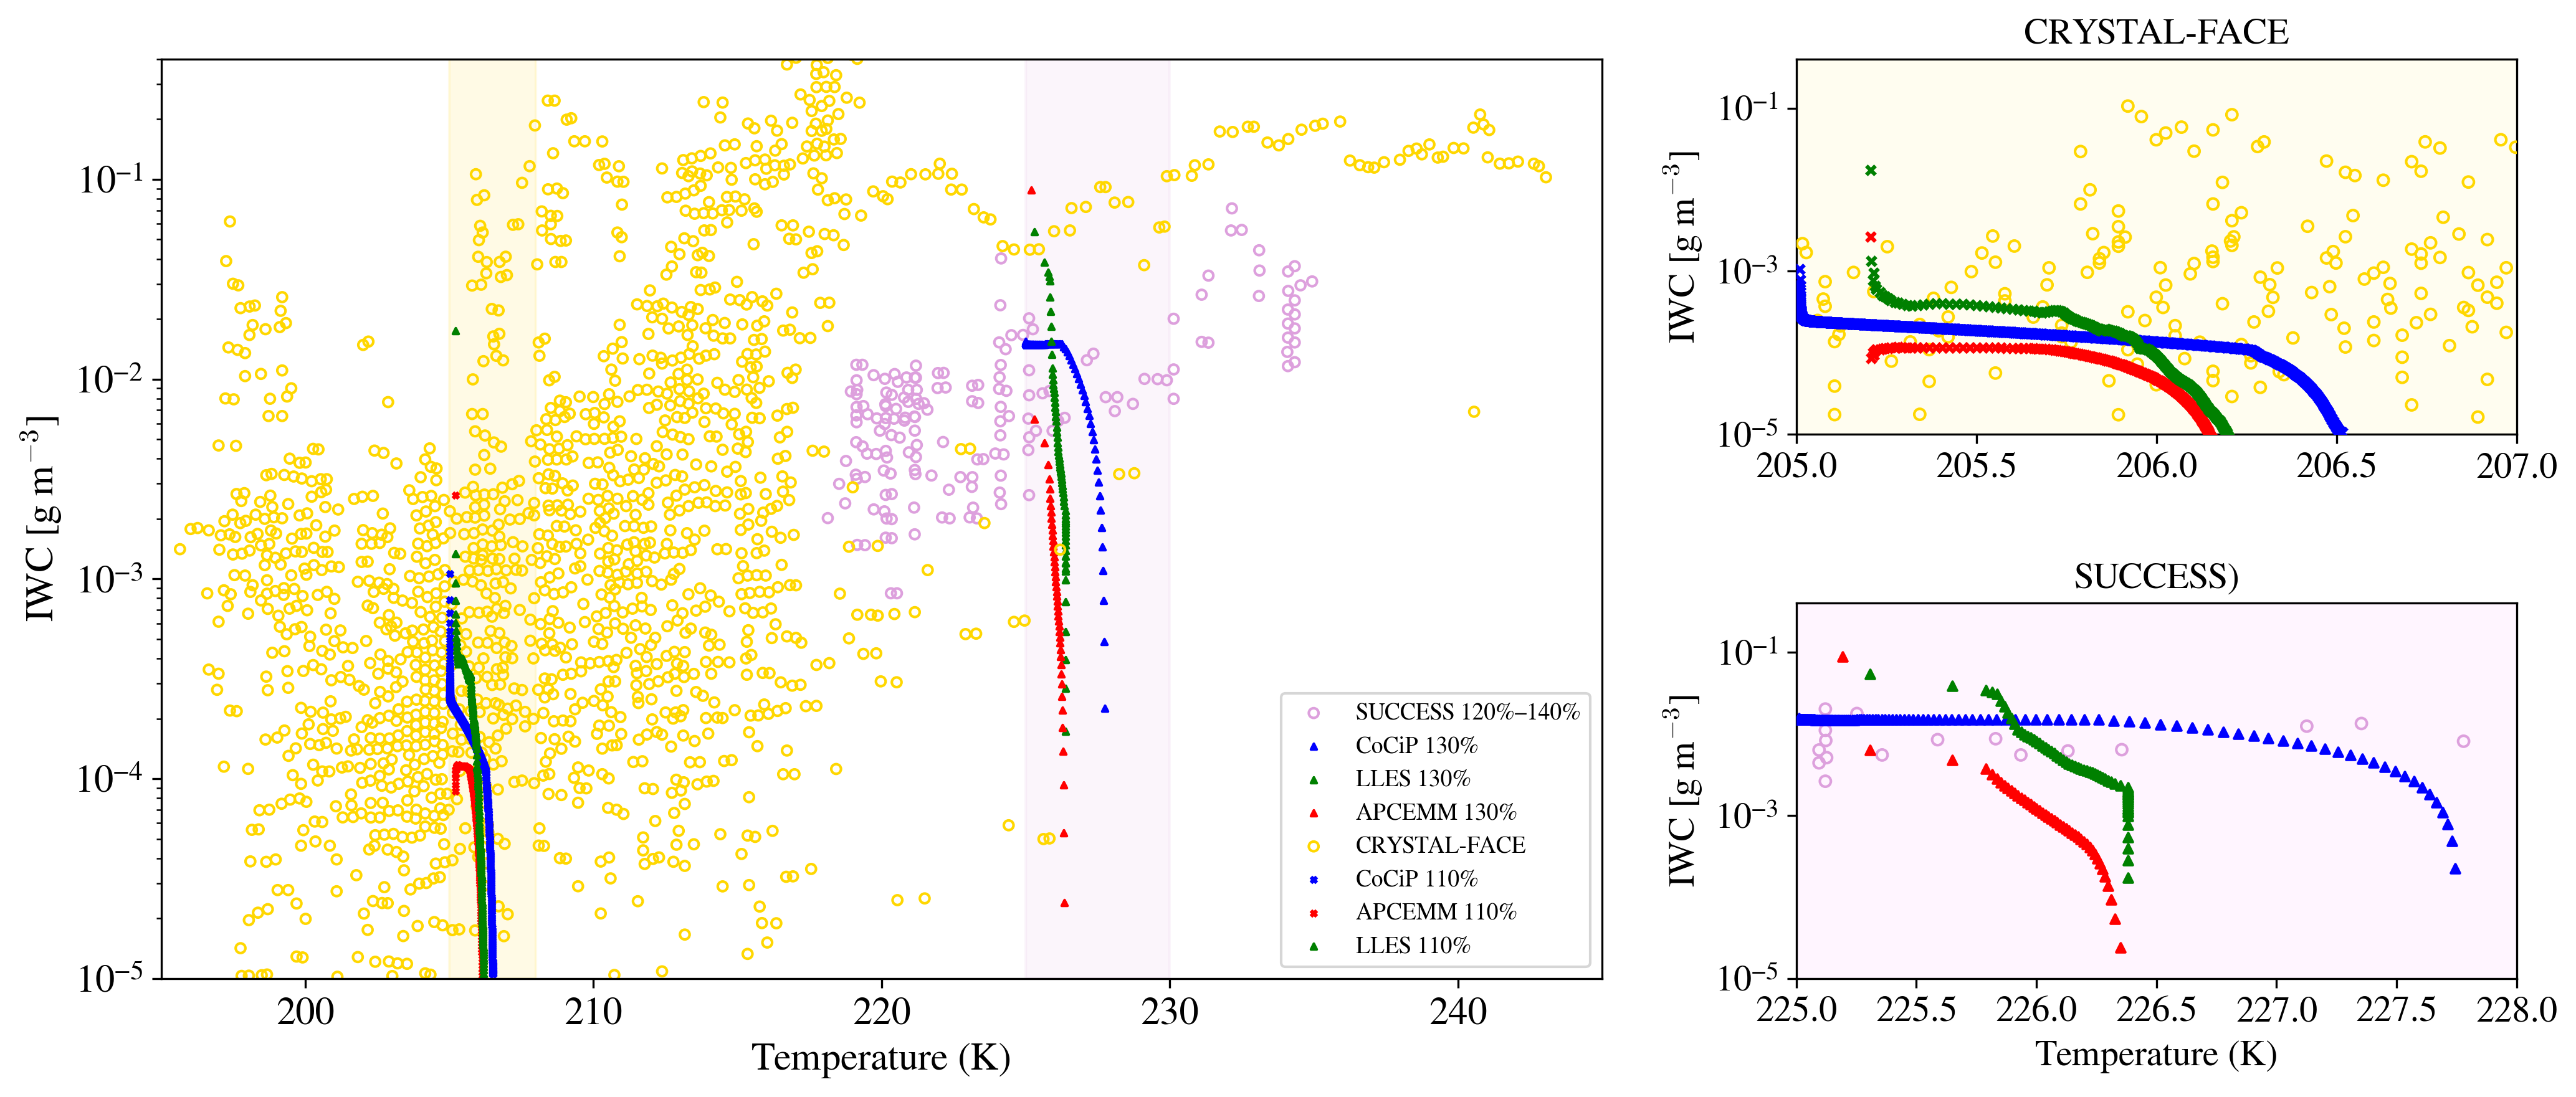

In [44]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 6), dpi=300)
plt.rcParams.update({'font.size': 15})

RHi_110_label = '110'
RHi_130_label = '130'

# ── Layout: main plot left (2/3 width), two stacked subplots right (1/3 width) ──
gs = gridspec.GridSpec(
    2, 2,
    width_ratios=[2, 1],
    hspace=0.45,
    wspace=0.18,
    left=0.07, right=0.97,
    top=0.92, bottom=0.10,
)

ax1    = fig.add_subplot(gs[:, 0])   # main plot spans both rows
ax_cf  = fig.add_subplot(gs[0, 1])   # upper right: CRYSTAL-FACE (205–208 K)
ax_suc = fig.add_subplot(gs[1, 1])   # lower right: SUCCESS (225–230 K)

# ════════════════════════════════════════════════════════════════════════════════
# ── Main plot ────────────────────────────────────────────────────────────────
# ════════════════════════════════════════════════════════════════════════════════

# SUCCESS 130% 225K
ax1.scatter(SUCCESS_temperature.values, SUCCESS_IWC.values,
            marker='o', label='SUCCESS 120%–140%', edgecolor='plum', s=14, facecolor='none')
ax1.scatter(cocip_temperature_130_225, cocip_IWC_130_225,
            marker='^', label=f'CoCiP {RHi_130_label}%', color='blue', s=5)
ax1.scatter(LLES_temperature_130_225, LLES_IWC_130_225,
            marker='^', label=f'LLES {RHi_130_label}%', color='green', s=5)
ax1.scatter(APCEMM_temperature_at_centroid_130_225, APCEMM_IWC_130_225,
            marker='^', label=f'APCEMM {RHi_130_label}%', color='red', s=5)

# CRYSTAL-FACE 110% 205K
ax1.scatter(CF_temperature.values, CF_IWC.values,
            marker='o', label='CRYSTAL-FACE', edgecolor='gold', s=14, facecolor='none')
ax1.scatter(cocip_temperature_110_205, cocip_IWC_110_205,
            marker='x', label=f'CoCiP {RHi_110_label}%', color='blue', s=5)
ax1.scatter(APCEMM_temperature_at_centroid_110_205, APCEMM_IWC_110_205,
            marker='x', label=f'APCEMM {RHi_110_label}%', color='red', s=5)
ax1.scatter(LLES_temperature_110_205, LLES_IWC_110_205,
            marker='^', label=f'LLES {RHi_110_label}%', color='green', s=5)

# ax1.errorbar(SUCCESS_TEMP_PEN1, SUCCESS_IWC_PEN1, yerr=SUCCESS_IWC_PEN1_ERR,
#              marker='D', label='SUCCESS Mean IWC for PEN1',
#              color='darkblue', capsize=5)
# ax1.errorbar(SUCCESS_TEMP_PEN2, SUCCESS_IWC_PEN2, yerr=SUCCESS_IWC_PEN2_ERR,
#              marker='D', label='SUCCESS Mean IWC for PEN2',
#              color='pink', capsize=5)

# shaded bands showing the zoom regions
ax1.axvspan(205, 208, color='gold',  alpha=0.10, zorder=0)
ax1.axvspan(225, 230, color='plum',  alpha=0.10, zorder=0)

# ax1.set_title("IWC Reported from Experimental Campaigns")
ax1.set_xlim(195, 245)
ax1.set_ylim(1e-5, 4e-1)
ax1.set_yscale('log')
ax1.set_xlabel('Temperature (K)')
ax1.set_ylabel('IWC [g m$^{-3}$]')
ax1.legend(ncol=1, fontsize=9, loc='lower right')

# ════════════════════════════════════════════════════════════════════════════════
# ── Upper right: CRYSTAL-FACE range  205–208 K ───────────────────────────────
# ════════════════════════════════════════════════════════════════════════════════

T_lo_cf, T_hi_cf = 205, 207

ax_cf.scatter(CF_temperature.values, CF_IWC.values,
              marker='o', edgecolor='gold', s=18, facecolor='none', zorder=3)
ax_cf.scatter(cocip_temperature_110_205, cocip_IWC_110_205,
              marker='x', color='blue', s=12, zorder=3)
ax_cf.scatter(APCEMM_temperature_at_centroid_110_205, APCEMM_IWC_110_205,
              marker='x', color='red', s=12, zorder=3)
ax_cf.scatter(LLES_temperature_110_205, LLES_IWC_110_205,
              marker='x', color='green', s=12, zorder=3)

ax_cf.set_xlim(T_lo_cf, T_hi_cf)
ax_cf.set_ylim(1e-5, 4e-1)
ax_cf.set_yscale('log')
# ax_cf.set_xlabel('Temperature (K)', fontsize=14)
ax_cf.set_ylabel('IWC [g m$^{-3}$]', fontsize=14)
ax_cf.set_title(f'CRYSTAL-FACE', fontsize=14)
ax_cf.tick_params(labelsize=14)
ax_cf.set_facecolor('#fffdf0')   # faint gold tint to match band


# ════════════════════════════════════════════════════════════════════════════════
# ── Lower right: SUCCESS range  225–230 K ────────────────────────────────────
# ════════════════════════════════════════════════════════════════════════════════

T_lo_suc, T_hi_suc = 225, 228

ax_suc.scatter(SUCCESS_temperature.values, SUCCESS_IWC.values,
               marker='o', edgecolor='plum', s=18, facecolor='none', zorder=3)
ax_suc.scatter(cocip_temperature_130_225, cocip_IWC_130_225,
               marker='^', color='blue', s=12, zorder=3)
ax_suc.scatter(LLES_temperature_130_225, LLES_IWC_130_225,
               marker='^', color='green', s=12, zorder=3)
ax_suc.scatter(APCEMM_temperature_at_centroid_130_225, APCEMM_IWC_130_225,
               marker='^', color='red', s=12, zorder=3)
# ax_suc.errorbar(SUCCESS_TEMP_PEN1, SUCCESS_IWC_PEN1, yerr=SUCCESS_IWC_PEN1_ERR,
#                 marker='D', color='darkblue', capsize=4, ms=5)
# ax_suc.errorbar(SUCCESS_TEMP_PEN2, SUCCESS_IWC_PEN2, yerr=SUCCESS_IWC_PEN2_ERR,
#                 marker='D', color='pink', capsize=4, ms=5)

ax_suc.set_xlim(T_lo_suc, T_hi_suc)
ax_suc.set_ylim(1e-5, 4e-1)
ax_suc.set_yscale('log')
ax_suc.set_xlabel('Temperature (K)', fontsize=14)
ax_suc.set_ylabel('IWC [g m$^{-3}$]', fontsize=14)
ax_suc.set_title(f'SUCCESS)', fontsize=14)
ax_suc.tick_params(labelsize=14)
ax_suc.set_facecolor('#fff5ff')   # faint plum tint to match band

fig.show()

# Diameter comparisons

## Import mean mass diameter from SUCCESS campaign

In [45]:
def calculate_ACCRI_mmwD(IWC, crystals_per_m, contrail_area):
    # N is the total ice particle number concentration [#/cm3]
    # IWC is the ice water content [g/m3]
    # mmwD is the mean mass-weighted diameter [microns]
    IWC = IWC * 1e6 # [g/m3] to [g/cm3]
    N = crystals_per_m / contrail_area * 1e-6 # [#/m]/[m2]*1e-6 = [#/cm3]
    mmwD = (6/np.pi * IWC/N)**(1/3) # [microns]

    return mmwD  # microns

# Calculate APCEMM contrail area and get number concentration

In [46]:
# Calculate APCEMM IWC from epm_bypass_data
APCEMM_num_timesteps_130_225 = len(apcemm_data_130_225)
APCEMM_times_130_225 = np.arange(APCEMM_num_timesteps_130_225) * 10 / 60  # time in hours

# Get the contrail area and number density for each timestep in epm_bypass_data[test_id]
APCEMM_area_130_225 = np.zeros(APCEMM_num_timesteps_130_225) # [m2]
APCEMM_num_130_225 = np.zeros(APCEMM_num_timesteps_130_225) # [#/m2]

for i in range(APCEMM_num_timesteps_130_225):
    iwc_2d = apcemm_data_130_225[i]["IWC"].values * 1e3  # Convert to g/m^3
    x = apcemm_data_130_225[i]["x"].values
    y = apcemm_data_130_225[i]["y"].values
    dx = np.abs(x[1] - x[0]) if len(x) > 1 else 1.0
    dy = np.abs(y[1] - y[0]) if len(y) > 1 else 1.0

    # Mask cells where IWC > 1e-4 (handles NaNs)
    valid_cells = (~np.isnan(iwc_2d)) & (iwc_2d > 1e-4)
    APCEMM_area_130_225[i] = np.count_nonzero(valid_cells) * dx * dy
    APCEMM_num_130_225[i] = apcemm_data_130_225[i]["Number Ice Particles"]  # [#/m]



## Get CoCiP contrail area and number concentration

In [47]:
cocip_area_130_225 = cocip_data_130_225['area_eff'].values  # [m2]
cocip_num_130_225 = cocip_data_130_225['n_ice_per_m'].values  # [#/m3]
cocip_num_timesteps_130_225 = len(cocip_times_130_225)

## Calculate mmwD for APCEMM and CoCiP for 130% 225K

In [48]:
APCEMM_mmwD_130_225 = np.zeros(APCEMM_num_timesteps_130_225) # [microns]
cocip_mmwD_130_225 = np.zeros(cocip_num_timesteps_130_225) # [microns]

for i in range(num_timesteps_130_225):
    APCEMM_mmwD_130_225[i] = calculate_ACCRI_mmwD(
        APCEMM_IWC_130_225[i], # [g/m3]
        APCEMM_num_130_225[i], # [#/m]
        APCEMM_area_130_225[i], # [m2]
    )
for i in range(cocip_num_timesteps_130_225):
    cocip_mmwD_130_225[i] = calculate_ACCRI_mmwD(
        cocip_IWC_130_225[i], # [g/m3]
        cocip_num_130_225[i], # [#/m]
        cocip_area_130_225[i], # [m2]
    )

/tmp/ipykernel_4027770/2043446045.py:6: RuntimeWarning: divide by zero encountered in double_scalars
  N = crystals_per_m / contrail_area * 1e-6 # [#/m]/[m2]*1e-6 = [#/cm3]


## Adding the actual experimental distributions

In [49]:
# Import the PSD from the SUCCESS campaign
SUCCESS_PSD_30min = pd.read_csv('/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/experimental_campaigns/SUCCESS/SUCCESS_PSD_Fig11b.csv')

SUCCESS_PSD_30min_conc = SUCCESS_PSD_30min['Conc [cm-3 miu-1]'].values # [cm-3 micron-1] Number of crystals per volume per radii
SUCCESS_PSD_30min_D = SUCCESS_PSD_30min['D [micron]'].values # [micron] Diameter

# Bin the PSD data by sorting the concentration points into diameter bins and taking the mean concentration in each bin
bin_edges = np.array([1, 1.02, 2.17, 4.42, 8.38, 14.01]) # microns
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
SUCCESS_PSD_30min_conc_binned = np.zeros(len(bin_centers))
for i in range(len(bin_centers)):
    in_bin = (SUCCESS_PSD_30min_D >= bin_edges[i]) & (SUCCESS_PSD_30min_D < bin_edges[i+1])
    if np.any(in_bin):
        SUCCESS_PSD_30min_conc_binned[i] = np.mean(SUCCESS_PSD_30min_conc[in_bin])
    else:
        SUCCESS_PSD_30min_conc_binned[i] = 0.0

SUCCESS_30min_area = APCEMM_area_130_225[3]  # m2 at 30 min
SUCCESS_PSD_30min_logr_binned = SUCCESS_PSD_30min_conc_binned * 1e6 * SUCCESS_30min_area * np.log(10) * bin_centers/2  # Get dN/dlog(r) [#/m/micron]

SUCCESS_PSD_100min = pd.read_csv('/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/experimental_campaigns/SUCCESS/SUCCESS_PSD_Fig11c.csv')
SUCCESS_PSD_100min_conc = SUCCESS_PSD_100min['Conc [cm-3 miu-1]'].values # [cm-3 micron-1] Number of crystals per volume per radii
SUCCESS_PSD_100min_D = SUCCESS_PSD_100min['D [micron]'].values # [micron] Diameter

# Bin the PSD data by sorting the concentration points into diameter bins and taking the mean concentration in each bin
SUCCESS_PSD_100min_conc_binned = np.zeros(len(bin_centers))
for i in range(len(bin_centers)):
    in_bin = (SUCCESS_PSD_100min_D >= bin_edges[i]) & (SUCCESS_PSD_100min_D < bin_edges[i+1])
    if np.any(in_bin):
        SUCCESS_PSD_100min_conc_binned[i] = np.mean(SUCCESS_PSD_100min_conc[in_bin])
    else:
        SUCCESS_PSD_100min_conc_binned[i] = 0.0

SUCCESS_100min_area = APCEMM_area_130_225[6]  # m2 at 100 min

SUCCESS_PSD_100min_logr_binned = SUCCESS_PSD_100min_conc_binned * 1e6 * SUCCESS_100min_area * np.log(10) * bin_centers/2  # Get dN/dlog(r) [#/m/micron]


NameError: name 'SUCCESS_PSD_30min_logr' is not defined

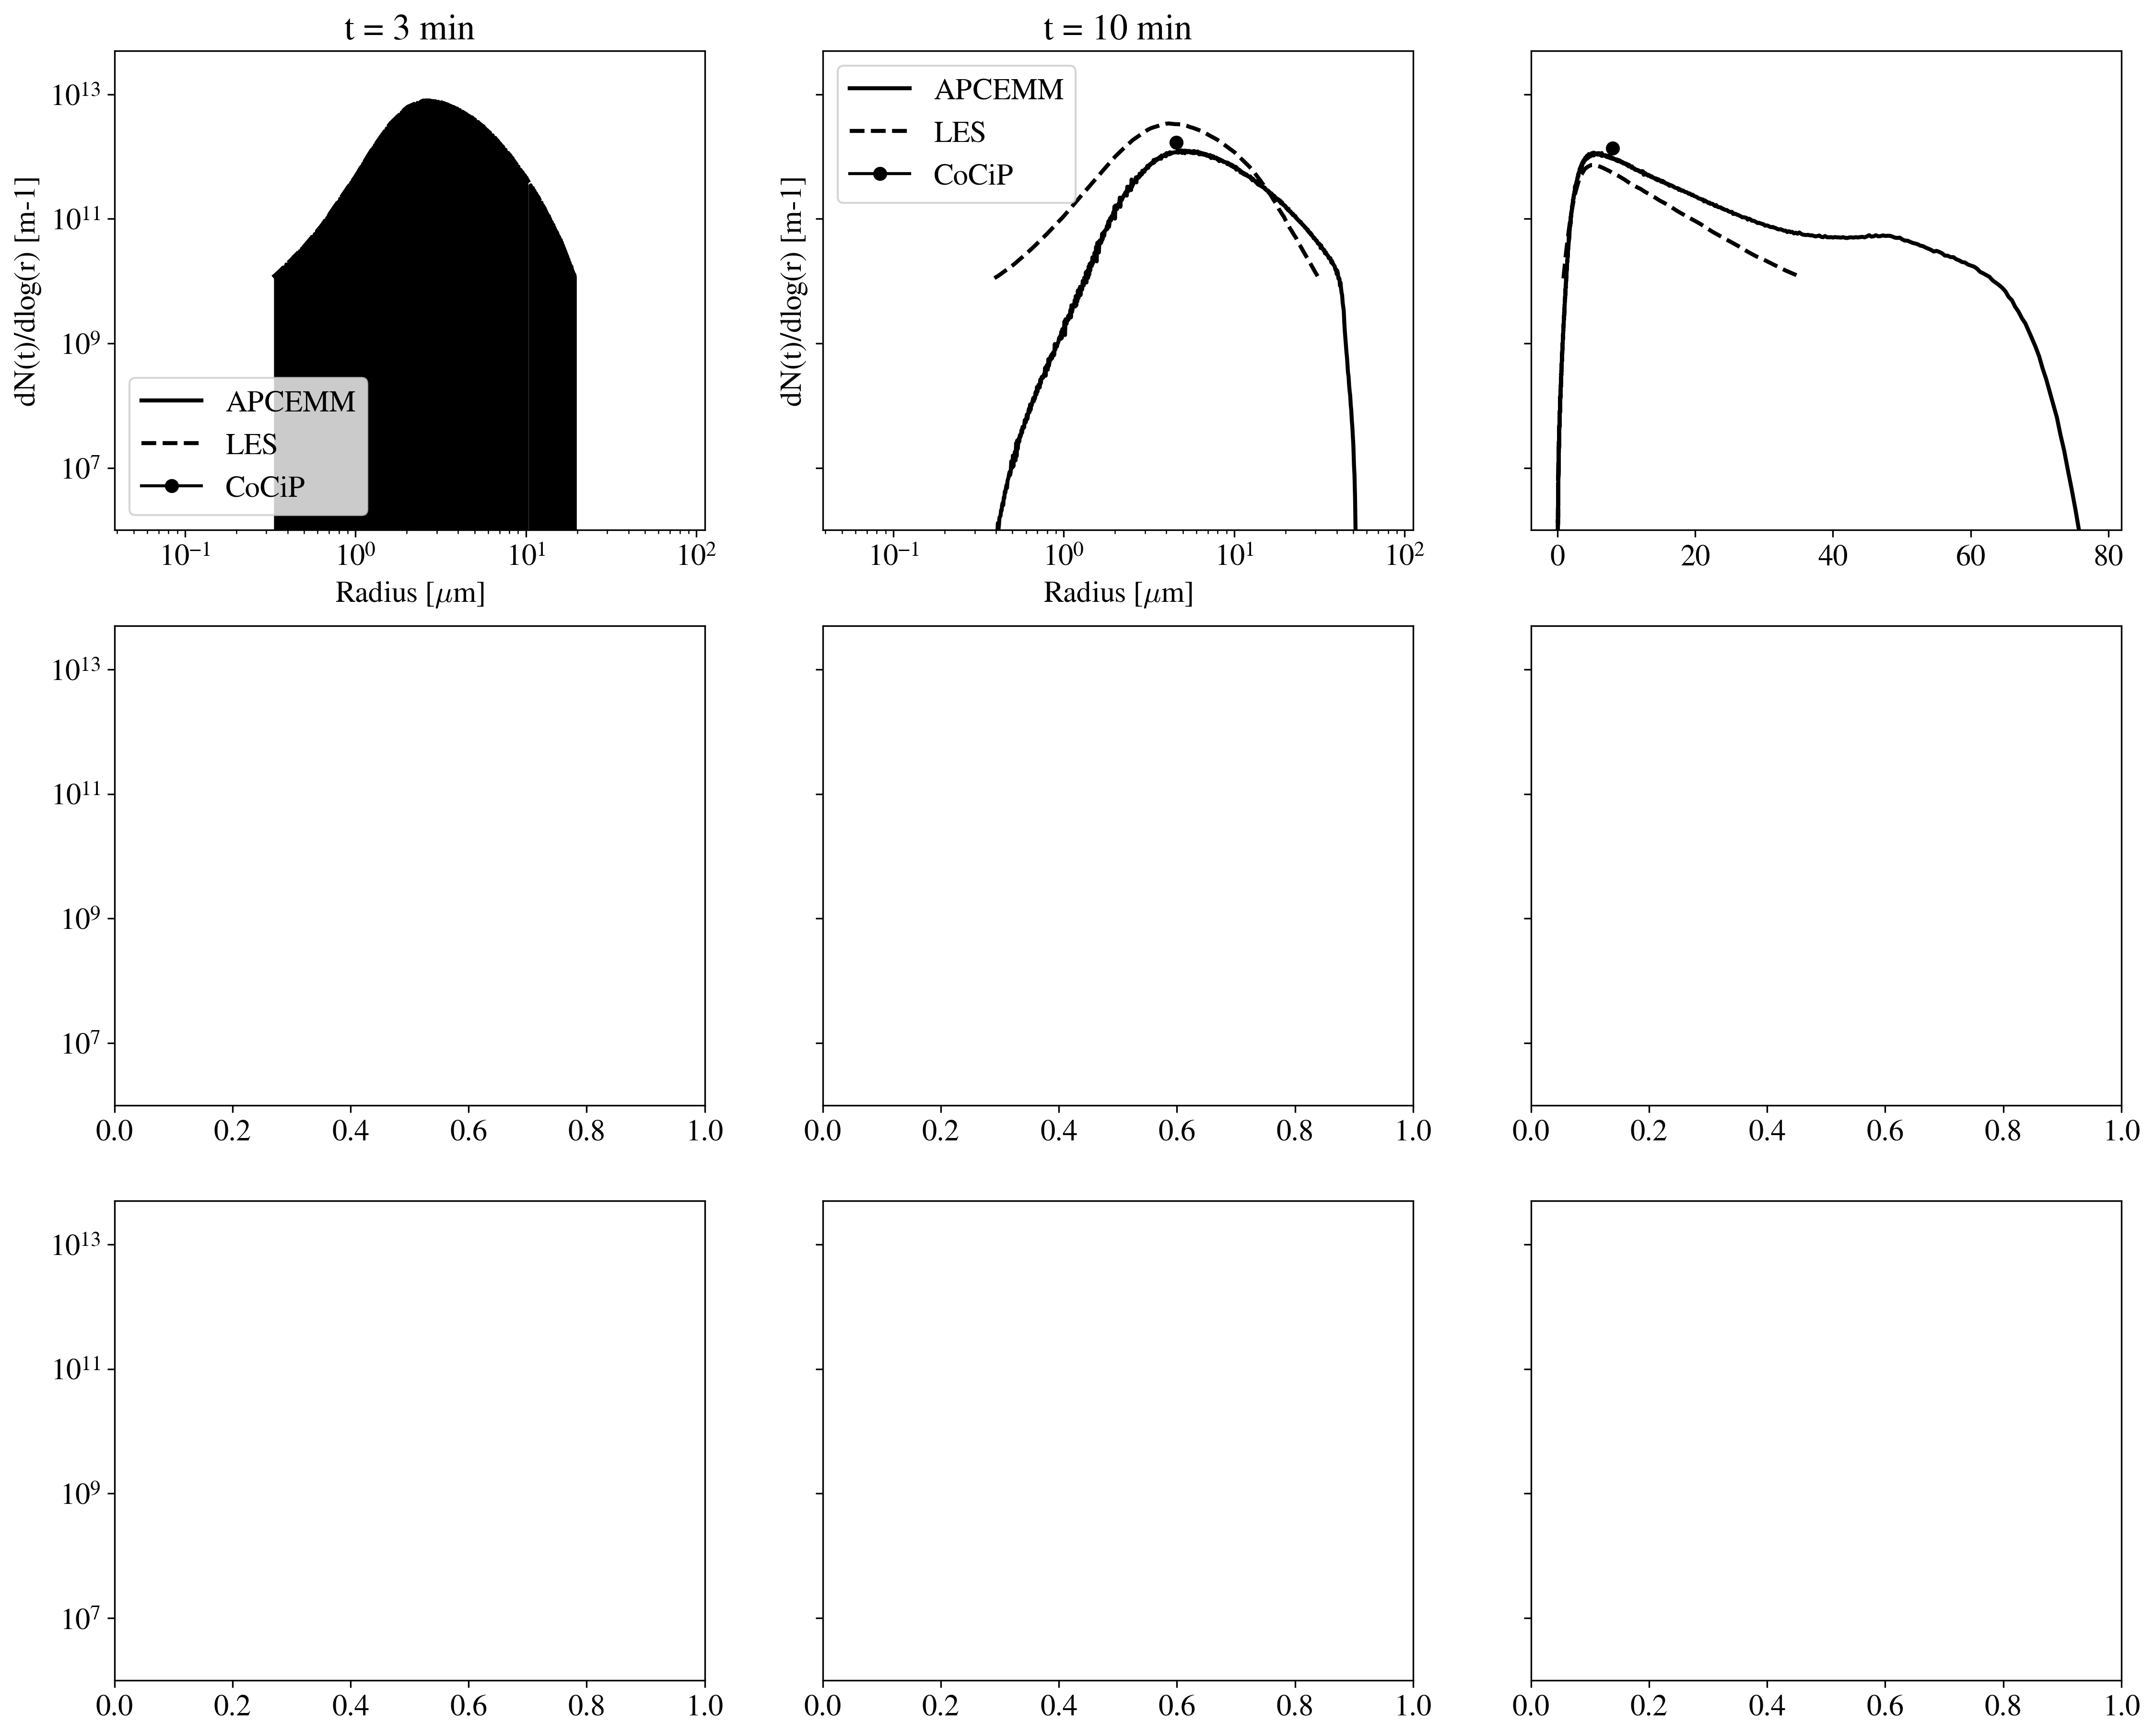

In [50]:
# Plotting each LES vs APCEMM vs CoCiP Radius Distribution in a 3x3 subplot grid
test_id = '130T225L25'
RHi = str(test_id[:3])
temp = test_id[4:7]

fig, axes = plt.subplots(3, 3, figsize=(18, 15), dpi=300, sharey=True)
axes = axes.flatten()

# Prepare the time indices
plot_times_min = [0, 10, 30, 60, 90, 180, 360, 540, 720]
plot_indices = [int(t / 10) for t in plot_times_min]

cocip_ds = cocip_data_130_225

# Sort LES files for this scenario
les_files = sorted(
    [f for f in radius_LES_csv if test_id in f],
    key=lambda x: int(re.search(r'_(\d+)min\.csv$', x).group(1))
)

for i, idx in enumerate(plot_indices):
    t_hr = plot_times_min[i] / 60
    ax = axes[i]
    color = 'black'

    # APCEMM
    ds = apcemm_data_130_225[idx]
    r_um = ds['r'].values * 1e6
    size_dist = removeLow(ds["Overall size distribution"].values, cutoff=1e-6)
    ax.plot(r_um, size_dist, label="APCEMM", color=color, lw=2)

    # # APCEMM mmwR
    # APCEMM_times = APCEMM_times_130_225
    # idx_APCEMM = (np.abs(APCEMM_times - t_hr)).argmin()
    
    # # Take the mean size distribution value for radius = mmwD/2
    # valid = size_dist > 0
    # if np.any(valid):
    #     mean_size = size_dist[valid].mean()
    # else:
    #     mean_size = 0.0
    # ax.plot([APCEMM_mmwD_130_225[idx_APCEMM]/2], [mean_size], marker='^', label="APCEMM mmwR", color='red', lw=2)

    # LES
    if i < len(les_files):
        df = pd.read_csv(les_files[i], header=None)
        if i == 0:
            scaling = size_dist.max() / df.iloc[:, 1].max()  # Scale LES to match APCEMM at the first timestep
        ax.plot(df.iloc[:,0], scaling*df.iloc[:,1], label="LES", color=color, linestyle='--', lw=2)

    # CoCiP
    cocip_times = cocip_ds['age_hours'].values
    # Only plot the CoCiP point at idx_cocip (closest time)
    if t_hr < cocip_times[-1]:
        idx_cocip = (np.abs(cocip_times - t_hr)).argmin()
        ax.plot(
            [cocip_data_130_225['r_ice_vol'].values[idx_cocip] * 1e6], # meter to micrometer
            [cocip_data_130_225['n_ice_per_m'].values[idx_cocip]],
            marker='o',
            color=color,
            label="CoCiP"
        )
    else:
        print(f"CoCiP data not available for t = {t_hr} hours")

    # # CoCiP mmwD
    # # Only plot the CoCiP point at idx_cocip (closest time)
    # if t_hr < cocip_times[-1]:
    #     idx_cocip = (np.abs(cocip_times - t_hr)).argmin()
    #     ax.plot(
    #         [cocip_mmwD_130_225[idx_cocip]/2], # mmwD to radius
    #         [cocip_data_130_225['n_ice_per_m'].values[idx_cocip]],
    #         marker='x',
    #         color='red',
    #         label="CoCiP mmwR"
    #     )
    # else:
    #     print(f"CoCiP mmwR data not available for t = {t_hr} hours")

    # SUCCESS PSD at 30 min
    if i == 2:
        ax.plot(SUCCESS_PSD_30min_D/2, SUCCESS_PSD_30min_logr, label='SUCCESS', color='purple')
        ax.axvline(x=0.3, color='gray', linestyle='--', label='MASP threshold')
    # SUCCESS PSD at 100 min
    if i == 4:
        ax.plot(SUCCESS_PSD_100min_D/2, SUCCESS_PSD_100min_logr, label='SUCCESS', color='purple')
        ax.axvline(x=0.3, color='gray', linestyle='--', label='MASP threshold')
    
    if i == 0:
        ax.set_title(f't = 3 min')
    else:
        ax.set_title(f't = {plot_times_min[i]} min')
    
    ax.set_yscale('log')
    ax.set_xscale('log')
    # ax.set_xlim(1e-1, 2e2)
    ax.set_ylim(1e6, 5e13)
    ax.set_xlabel('Radius [$\mu$m]')
    ax.set_ylabel('dN(t)/dlog(r) [m-1]')
    ax.legend()
plt.suptitle(f'Ice Crystal Radius Distribution Evolution \n RH$_i$ = {RHi}% T = {temp}K \n', fontsize=16)
plt.tight_layout()
plt.show()


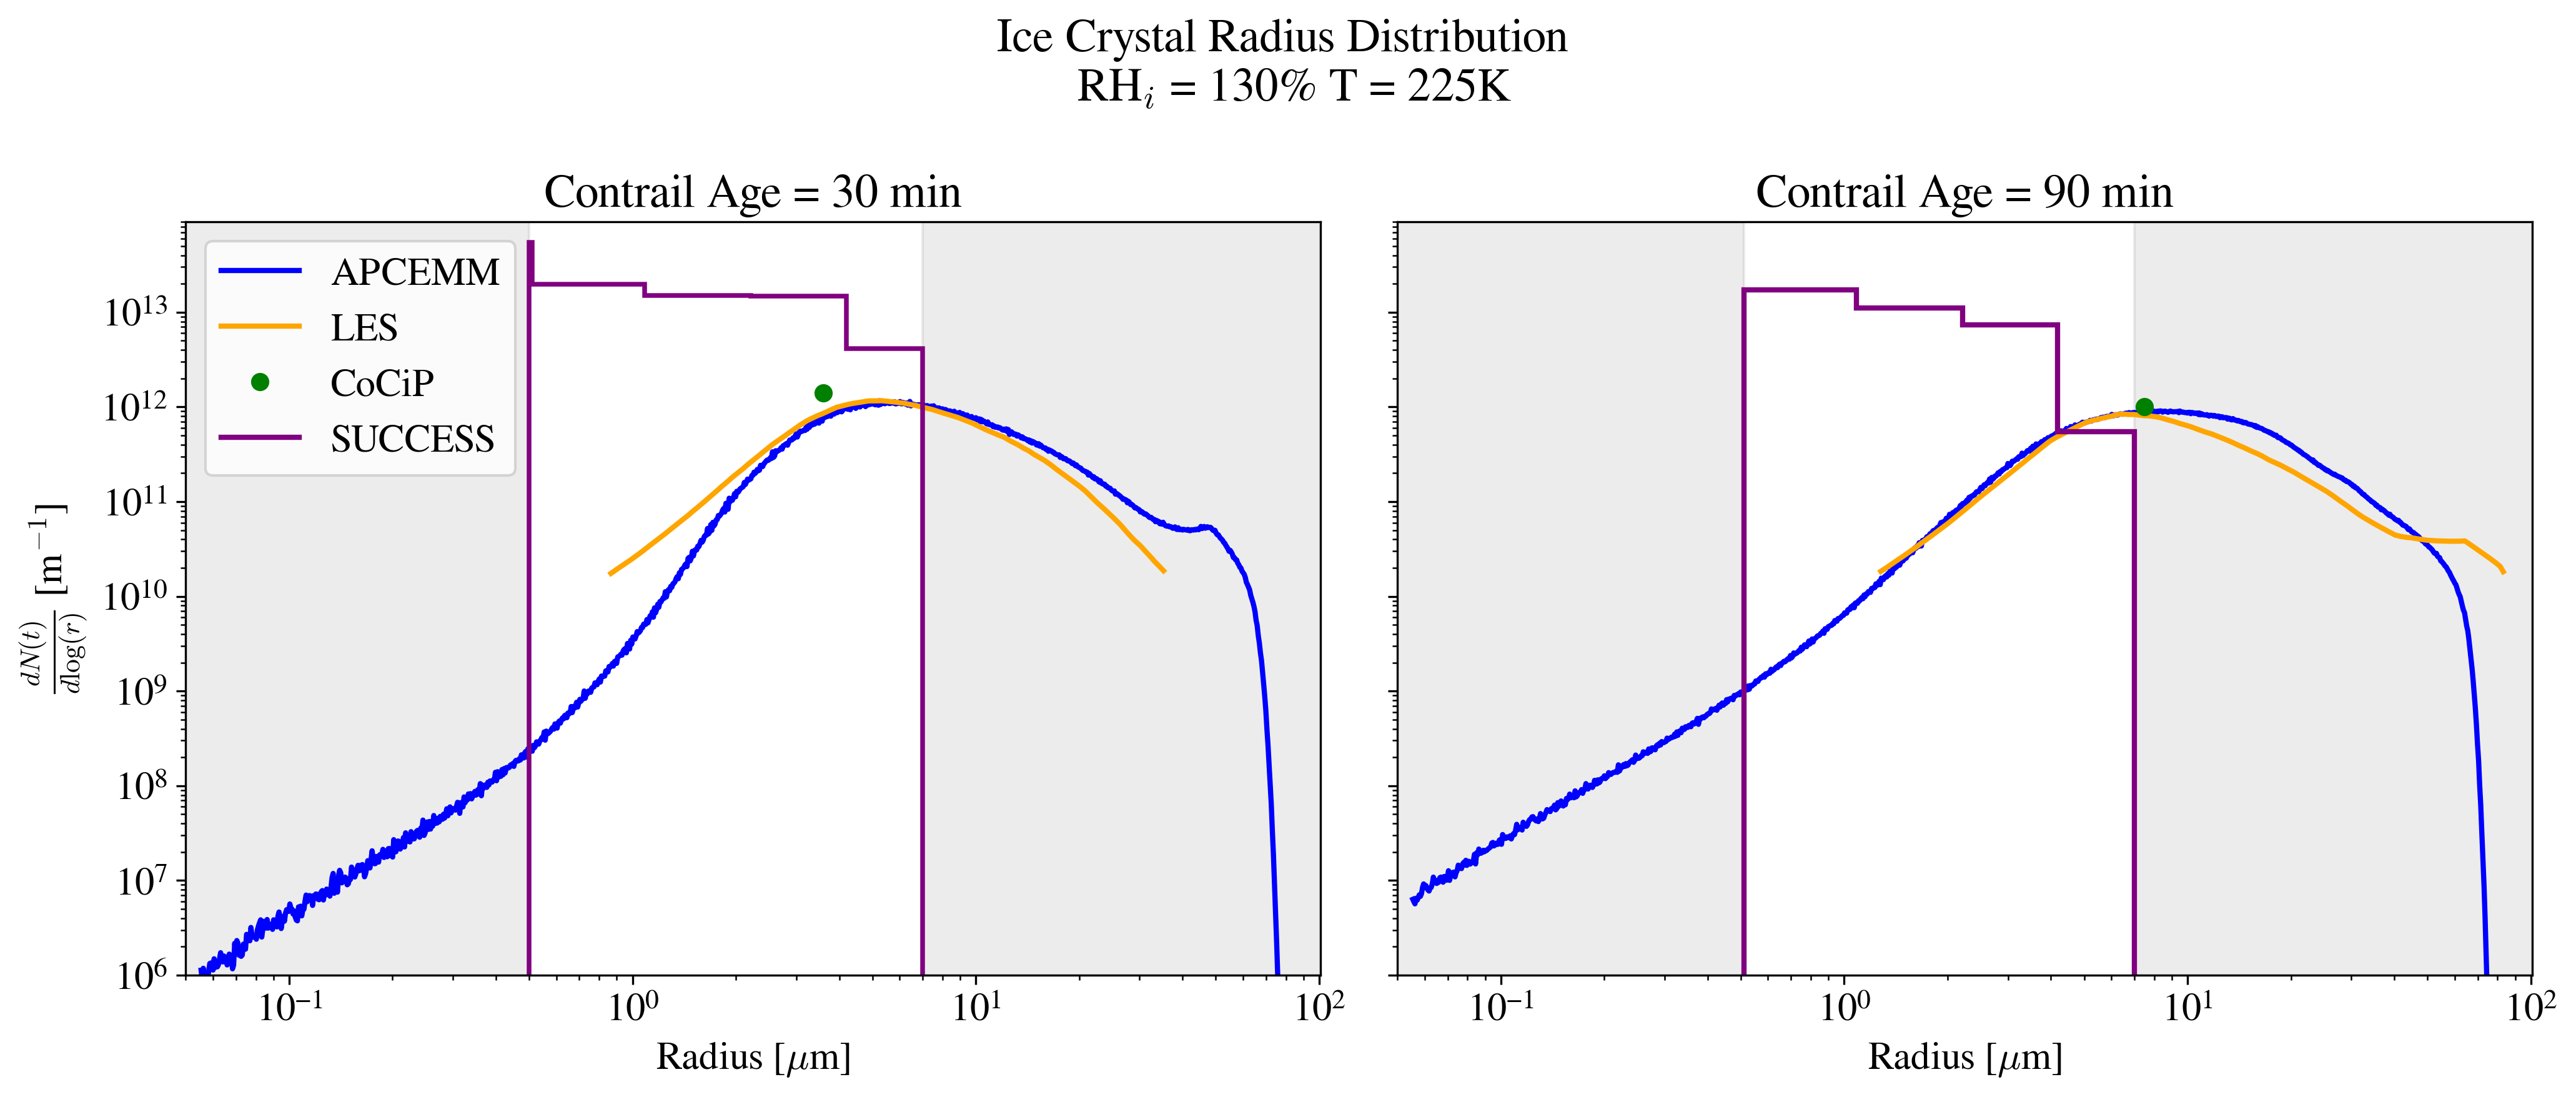

In [73]:
# Plot only the 30 and 90 minute subplots
selected_minutes = [30, 90]
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=300, sharey=True)
axes = axes.flatten()
plt.rcParams.update({'font.size': 15})

cocip_ds = cocip_data_130_225
scaling = None  # will set from the first LES we plot (30 min)
legend = False
for ax, t_min in zip(axes, selected_minutes):
    ax.set_xlim(5e-2,101)
    idx_apcemm = int(t_min / 10)
    t_hr = t_min / 60.0

    # APCEMM
    ds = apcemm_data_130_225[idx_apcemm]
    r_um = ds['r'].values * 1e6
    size_dist = removeLow(ds["Overall size distribution"].values, cutoff=1e-6)
    ax.plot(r_um, size_dist, label="APCEMM", color='blue', lw=2)

    # LES (find file for this minute)
    les_file = next((f for f in les_files if f.endswith(f'_{t_min}min.csv')), None)
    if les_file is not None:
        df = pd.read_csv(les_file, header=None)
        if scaling is None:
            scaling = size_dist.max() / df.iloc[:, 1].max()
        ax.plot(df.iloc[:, 0], scaling * df.iloc[:, 1], label="LES", color='orange', lw=2)

    if t_min == 30:
        cocip_r = 3.6
        cocip_n = 1.4e12
    elif t_min == 90:
        cocip_r = 7.5
        cocip_n = 1e12

    ax.plot(cocip_r, cocip_n, marker='o', color='green', label='CoCiP', linestyle='None')


    if t_min == 30:
        ax.hist(
            bin_centers/2,
            bins=bin_edges/2,
            weights=SUCCESS_PSD_30min_logr_binned,
            histtype='step',
            color='purple',
            linewidth=1.8,
            label='SUCCESS'
        )
        ax.axvspan(ax.get_xlim()[0], 0.5, color='gray', alpha=0.15, zorder=0)
        ax.axvspan(7, ax.get_xlim()[1], color='gray', alpha=0.15, zorder=0)

    if t_min == 90:
        if 'SUCCESS_PSD_100min_D' in globals():
            ax.hist(
                bin_centers/2,
                bins=bin_edges/2,
                weights=SUCCESS_PSD_100min_logr_binned,
                histtype='step',
                color='purple',
                linewidth=2,
                label='SUCCESS'
            )
        ax.axvspan(ax.get_xlim()[0], 0.51, color='gray', alpha=0.15, zorder=0)
        ax.axvspan(7, ax.get_xlim()[1], color='gray', alpha=0.15, zorder=0)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylim(1e6, 9e13)
    ax.set_xlabel('Radius [$\\mu$m]')
    ax.set_title(f'Contrail Age = {t_min} min')
    if ax is axes[0]:
        ax.set_ylabel(r'$\frac{dN(t)}{d\log(r)}$ [m$^{-1}$]')
    handles, labels = ax.get_legend_handles_labels()
    if 'SUCCESS' in labels:
        success_idx = labels.index('SUCCESS')
        handles[success_idx] = plt.Line2D([0], [0], color='purple', lw=2)
    if not legend:
        ax.legend(handles, labels)
        legend = True

plt.suptitle(f'Ice Crystal Radius Distribution \n RH$_i$ = {RHi}% T = {temp}K')
plt.tight_layout()
plt.show()
